## 1. Corellation

In [107]:
from datascience import *
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
plt.style.use('fivethirtyeight')


In [108]:
hybrid = Table.read_table('../../Data/hybrid.csv')
hybrid

vehicle,year,msrp,acceleration,mpg,class
Prius (1st Gen),1997,24509.7,7.46,41.26,Compact
Tino,2000,35355,8.2,54.1,Compact
Prius (2nd Gen),2000,26832.2,7.97,45.23,Compact
Insight,2000,18936.4,9.52,53,Two Seater
Civic (1st Gen),2001,25833.4,7.04,47.04,Compact
Insight,2001,19036.7,9.52,53,Two Seater
Insight,2002,19137,9.71,53,Two Seater
Alphard,2003,38084.8,8.33,40.46,Minivan
Insight,2003,19137,9.52,53,Two Seater
Civic,2003,14071.9,8.62,41,Compact


In [109]:
def standard_units(array):
    return (array - np.mean(array))/np.std(array)

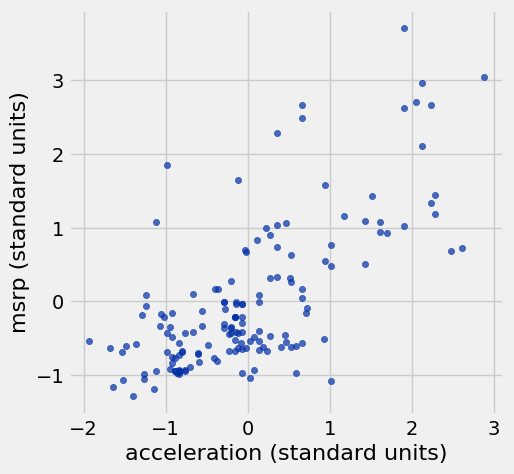

In [110]:
Table().with_columns(
    'acceleration (standard units)', standard_units(hybrid.column('acceleration')), 
    'msrp (standard units)',         standard_units(hybrid.column('msrp'))
).scatter(0, 1)

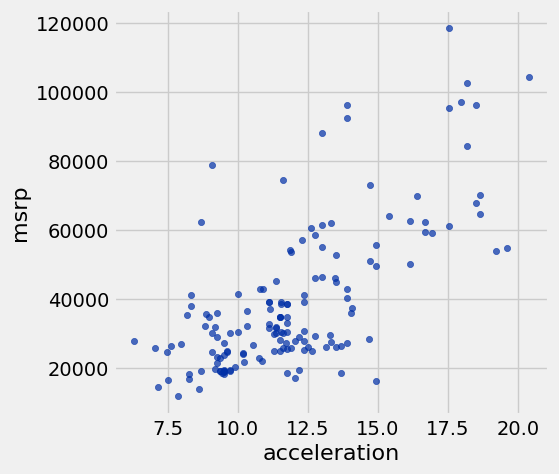

In [111]:
hybrid.scatter('acceleration','msrp')

Cach tinh r

In [112]:
x = np.arange(1,6,1)
y = np.arange(2,11,2)
z = Table().with_columns(
    'x',x,
    'y',y
)
z

x,y
1,2
2,4
3,6
4,8
5,10


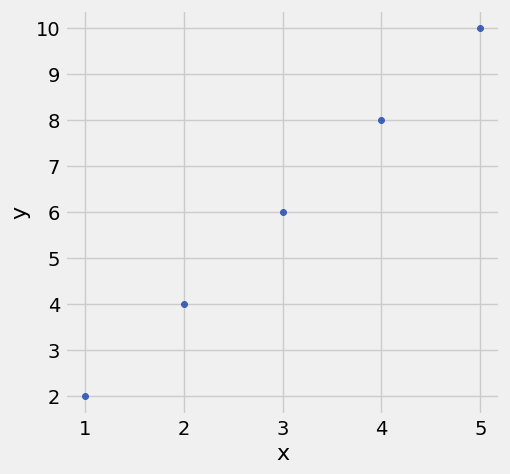

In [113]:
z.scatter('x','y')

In [114]:
z = z.with_columns(
    'standard_units(x)', standard_units(x),
    'standard_units(y)', standard_units(y)
)
z

x,y,standard_units(x),standard_units(y)
1,2,-1.41421,-1.41421
2,4,-0.707107,-0.707107
3,6,0,0
4,8,0.707107,0.707107
5,10,1.41421,1.41421


In [115]:
np.mean(z.column(2) * z.column(3))

0.99999999999999978

In [116]:
def correlation(t : Table, x : str,y : str)-> float:
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))
correlation(z,'x','y')    

0.99999999999999978

In [117]:
correlation(z,'y','x')

0.99999999999999978

2. regression line

In [118]:
heights = Table.read_table('../../Data/Galton_Family_Heights.csv')
heights

Father_height,Mother_height,Child_height,gender
78.5,67,73.2,1
78.5,67,69.2,0
78.5,67,69,0
78.5,67,69,0
75.5,66.5,73.5,1
75.5,66.5,72.5,1
75.5,66.5,65.5,0
75.5,66.5,65.5,0
75,64,71,1
75,64,68,0


In [119]:
heights_parent_sons = Table().with_columns(
    'Mid_parents', (heights.column(0) + heights.column(1))/2,
    'Child', heights.column(2)
)
heights_parent_sons

Mid_parents,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5
71,72.5
71,65.5
71,65.5
69.5,71
69.5,68


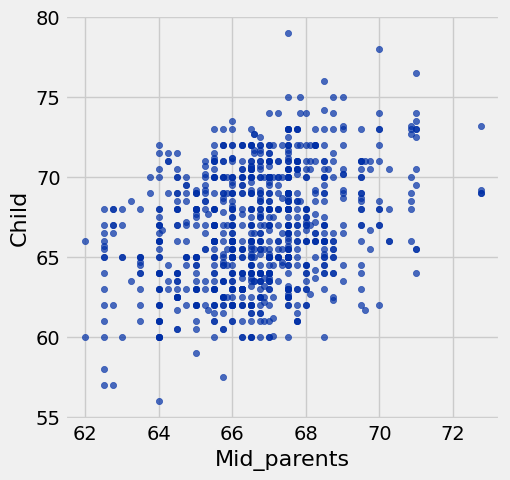

In [120]:
heights_parent_sons.scatter('Mid_parents')

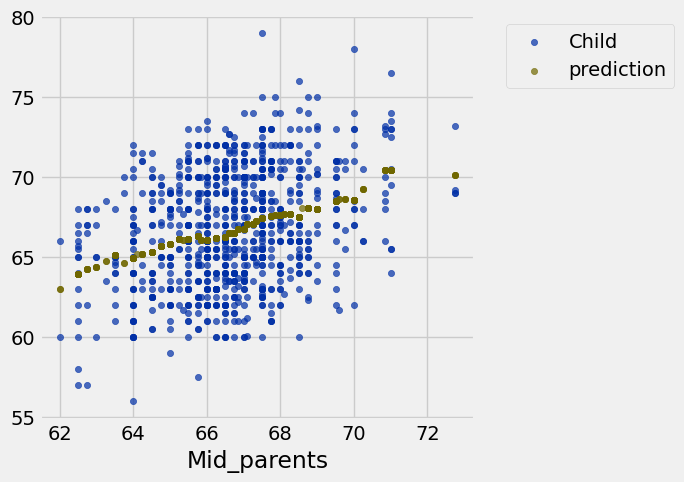

In [121]:
def interval(mph):
    result = heights_parent_sons.where('Mid_parents',are.between(mph- 0.5,mph+0.5))
    return np.mean(result.column(1))
heights_parent_sons = heights_parent_sons.with_column(
    'prediction' , heights_parent_sons.apply(interval,'Mid_parents')
)
heights_parent_sons.scatter('Mid_parents')

In [122]:
heights_std = Table().with_columns(
    'Mid parents_std', standard_units(heights_parent_sons.column(0)),
    'Child_std',standard_units(heights_parent_sons.column(1))
)
heights_std

Mid parents_std,Child_std
3.51798,1.80416
3.51798,0.686005
3.51798,0.630097
3.51798,0.630097
2.50985,1.88802
2.50985,1.60848
2.50985,-0.348285
2.50985,-0.348285
1.64573,1.18917
1.64573,0.350559


In [123]:
k = 0.5/np.std(heights_parent_sons.column(0))
k

0.28803801654821198

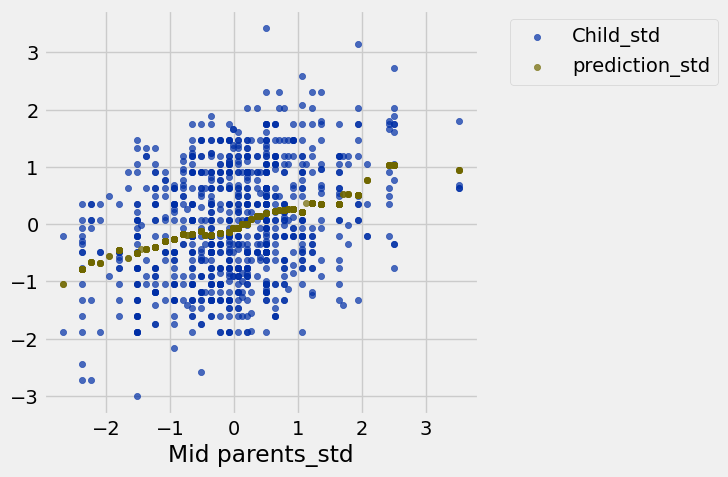

In [124]:
def prediction_child_std(mph):
    child = heights_std.where('Mid parents_std', are.between(mph - k,mph+k)) 
    return np.mean(child.column(1))
heights_std = heights_std.with_column(
    'prediction_std', heights_std.apply(prediction_child_std,'Mid parents_std')
)
heights_std.scatter('Mid parents_std')

In [125]:
def slope(t,label_1,label_2):
    return correlation(t,label_1,label_2) * np.std(t.column(label_2))/np.std(t.column(label_1))

def intercept(t,label_1,label_2):
    return np.mean(t.column(label_2)) - slope(t,label_1,label_2) * np.mean(t.column(label_1))

In [126]:
family_r = correlation(heights_parent_sons,'Mid_parents','Child')
family_r

0.32244267720033076

In [127]:
family_slope = slope(heights_parent_sons,'Mid_parents','Child')
family_slope

0.66449526235258838

In [128]:
family_intercept = intercept(heights_parent_sons,'Mid_parents','Child')
family_intercept

22.461839955758798

In [129]:
heights_parent_sons = heights_parent_sons.with_column(
    'Regression prediction',family_slope * heights_parent_sons.column('Mid_parents') + family_intercept 
)
heights_parent_sons

Mid_parents,Child,prediction,Regression prediction
72.75,73.2,70.1,70.8039
72.75,69.2,70.1,70.8039
72.75,69,70.1,70.8039
72.75,69,70.1,70.8039
71,73.5,70.4158,69.641
71,72.5,70.4158,69.641
71,65.5,70.4158,69.641
71,65.5,70.4158,69.641
69.5,71,68.5025,68.6443
69.5,68,68.5025,68.6443


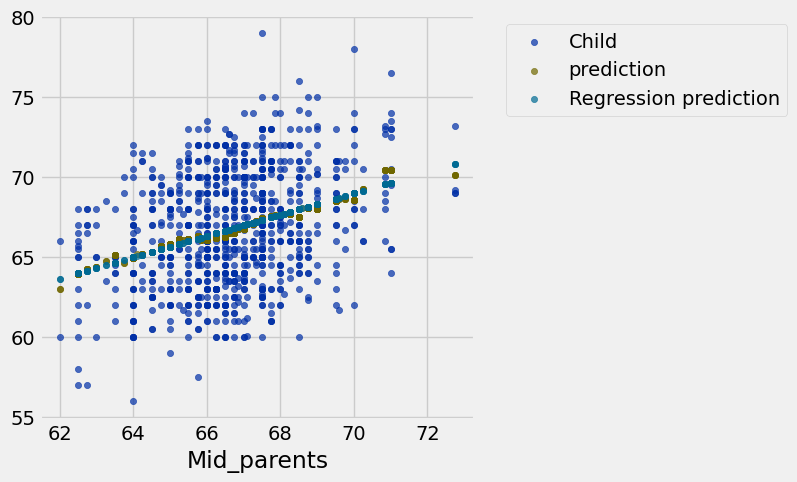

In [130]:
heights_parent_sons.scatter('Mid_parents')

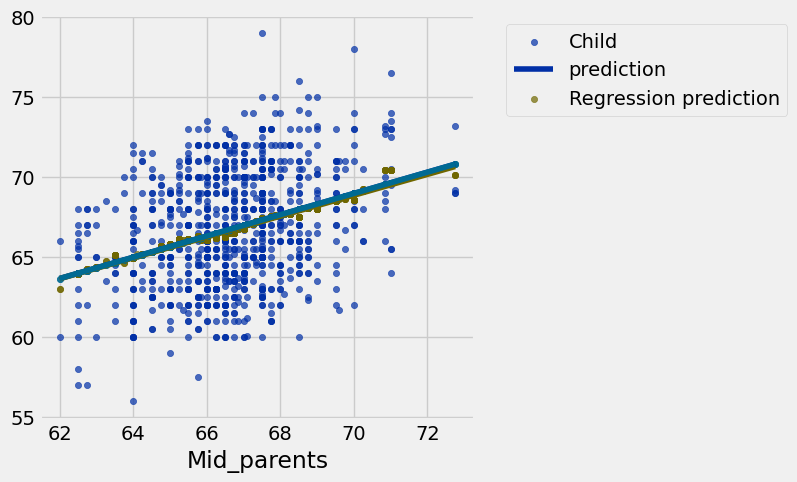

In [131]:
heights_parent_sons.scatter('Mid_parents',fit_line = True)

Ting cac sai so uoc luong (root mean square errors)

In [132]:
def lh_rmse(params):
    x = heights_parent_sons.column('Mid_parents')
    y = heights_parent_sons.column('Child')
    slope,intercept = params
    fitted = slope*x + intercept
    mse  = np.mean((y - fitted) ** 2)
    return mse** 0.5
lh_rmse([family_slope,family_intercept])


3.3862655542854498

In [133]:
from scipy.optimize import minimize
result = minimize(lh_rmse, x0=[0,0])
print(result.x)
print(family_slope)
print(family_intercept)

[  0.66448487  22.46253243]
0.664495262353
22.4618399558


Duong hoi quy binh phuong nho nhat

In [134]:
shotput = Table.read_table('../../Data/shotputt_powerclean.csv')
shotput

power.clean,shot.putt
37.5,6.4
51.5,10.2
61.3,12.4
61.3,13
63.6,13.2
66.1,13
70,12.7
92.7,13.9
90.5,15.5
90.5,15.8


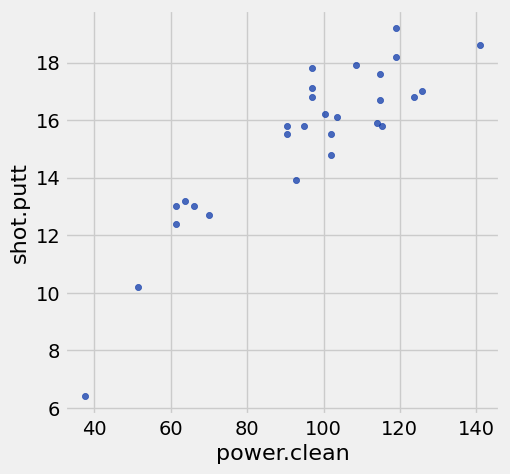

In [135]:
shotput.scatter('power.clean')

In [136]:
shotput_slope = slope(shotput,'power.clean','shot.putt')
shotput_slope

0.098343821597819972

In [137]:
shotput_intercept = intercept(shotput,'power.clean','shot.putt')
shotput_intercept

5.9596290983739522

In [138]:
shotput = shotput.with_column(
    'Regression line', shotput_slope*shotput.column(0) + shotput_intercept
)
shotput

power.clean,shot.putt,Regression line
37.5,6.4,9.64752
51.5,10.2,11.0243
61.3,12.4,11.9881
61.3,13,11.9881
63.6,13.2,12.2143
66.1,13,12.4602
70,12.7,12.8437
92.7,13.9,15.0761
90.5,15.5,14.8597
90.5,15.8,14.8597


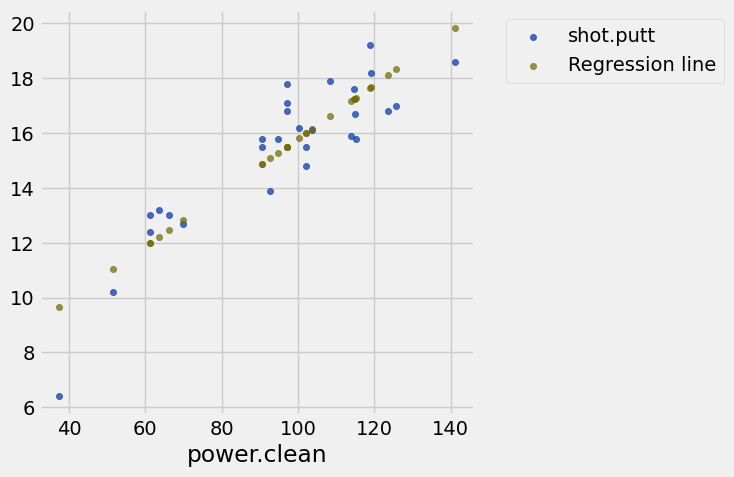

In [139]:
shotput.scatter('power.clean')

In [140]:
def shotput_mse(slope,intercept):
    x = shotput.column(0)
    y = shotput.column(1)
    fitted = slope* x + intercept
    return np.mean((fitted - y) ** 2)
shotput_mse(shotput_slope,shotput_intercept)

1.4870448507917486

In [141]:
from datascience import minimize
minimize(shotput_mse)

array([ 0.09834382,  5.95962911])

Nolinear regression

In [142]:
def shot_quadaric_mse(a,b,c):
    x = shotput.column('power.clean')
    y = shotput.column('shot.putt')
    fitted = a*(x**2) + b*x + c
    return np.mean((fitted - y) **2)
mini = minimize(shot_quadaric_mse)
mini

array([ -1.04004838e-03,   2.82708045e-01,  -1.53182115e+00])

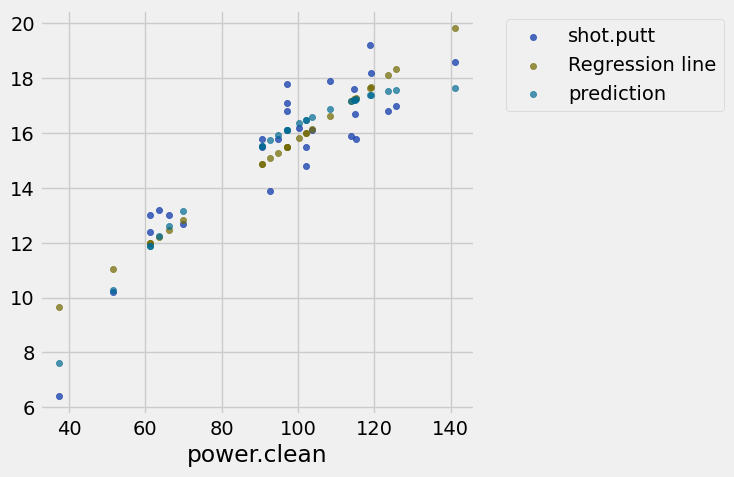

In [143]:
x = shotput.column(0)
predict_array = mini.item(0)*(x**2) + mini.item(1) * x + mini.item(2)
shotput = shotput.with_column(
    'prediction', predict_array
)
shotput.scatter('power.clean')

In [144]:
def fit(table,x,y):
    return slope(table,x,y)*table.column(x) + intercept(table,x,y)

Bieu do phan du de chan doan no mot duong hoi quy tuyen tinh hay phi tuyen tinh dua vao su dong deu quanh truc 0

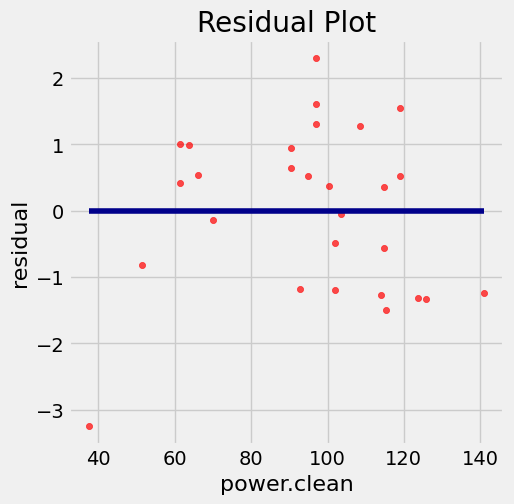

In [150]:
def residual_plots(table,x,y):
    x_array = table.column(x)
    residual = table.column(y) - fit(table,x,y)
    residual_table = Table().with_columns(
        x , x_array,
        'residual', residual
    )
    residual_table.scatter(x,'residual',color = 'r')
    xlims = make_array(min(x_array), max(x_array))
    plt.plot(xlims, make_array(0, 0), color='darkblue', lw=4)
    plt.title('Residual Plot')
residual_plots(shotput,'power.clean','shot.putt')
